# Exemplu Tabla

Dataset-ul pentru antrenare:


,Vreme,Umiditate,Vant,Alergam
0,0,1,0,0
1,0,1,1,0
2,1,1,0,1
3,2,1,0,1
4,2,0,0,1
5,2,0,1,0
6,1,0,1,1
7,0,1,0,0


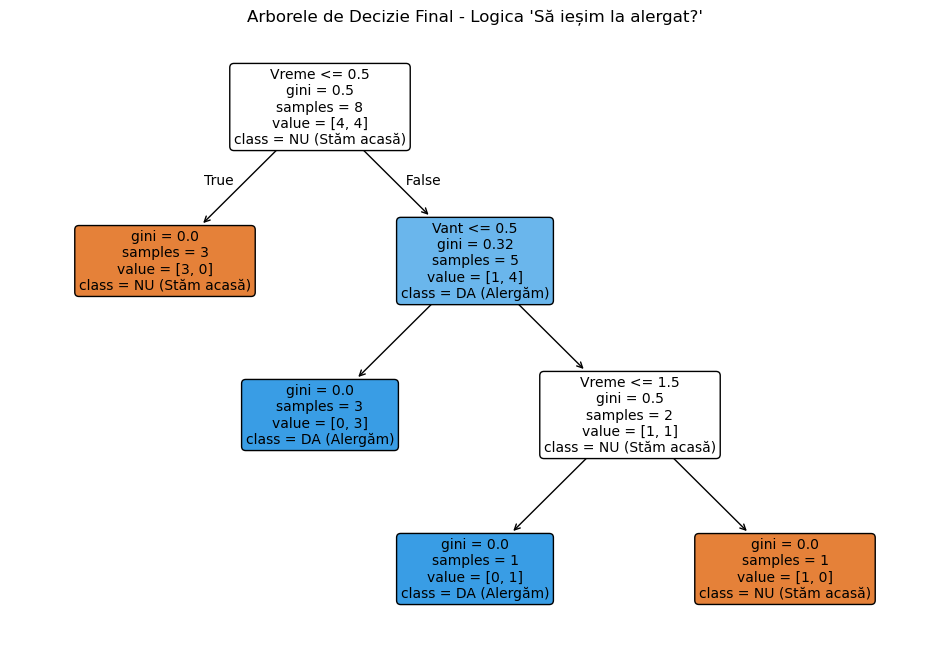

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Creăm setul de date (Varianta numerică pentru Scikit-Learn)
# Vreme: 0=Sunny, 1=Overcast, 2=Rain
# Umiditate: 0=Normal, 1=Ridicată
# Vânt: 0=Slab, 1=Puternic
data = {
    'Vreme': [0, 0, 1, 2, 2, 2, 1, 0], 
    'Umiditate': [1, 1, 1, 1, 0, 0, 0, 1],
    'Vant': [0, 1, 0, 0, 0, 1, 1, 0],
    'Alergam': [0, 0, 1, 1, 1, 0, 1, 0] # 0=NU, 1=DA
}

df_final = pd.DataFrame(data)

# Afișăm tabelul ca să vadă cursanții corespondența
print("Dataset-ul pentru antrenare:")
display(df_final)

# 2. Antrenăm arborele (fără restricții pentru a ajunge la puritate 100%)
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(df_final[['Vreme', 'Umiditate', 'Vant']], df_final['Alergam'])

# 3. Vizualizarea grafică
plt.figure(figsize=(12, 8))
plot_tree(clf, 
          feature_names=['Vreme', 'Umiditate', 'Vant'], 
          class_names=['NU (Stăm acasă)', 'DA (Alergăm)'], 
          filled=True, 
          rounded=True, 
          fontsize=10)

plt.title("Arborele de Decizie Final - Logica 'Să ieșim la alergat?'")
plt.show()

# Exemplu arbori

In [6]:
import pandas as pd
from sklearn.datasets import load_iris

# Încărcăm datele într-un format tabelar (DataFrame) pentru claritate
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in iris.target]

# Afișăm primele 5 rânduri
print("Primele 5 rânduri din setul de date:")
display(df.head())

# Statistici de bază
print("\nStatistici descriptive:")
display(df.describe())

Primele 5 rânduri din setul de date:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Statistici descriptive:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Cum citim un Boxplot? (Ghid de supraviețuire statistică)

Acest grafic, numit și Box and Whisker Plot, este o modalitate standardizată de afișare a distribuției datelor pe baza unui rezumat din cinci numere. Diagramele box plot sunt utile pentru identificarea valorilor de tip "zgomot" (outliers) și pentru compararea distribuțiilor între mai multe grupuri sau seturi de date.

Descifrarea elementelor:
- Lower Quartile (Q1): Marginea stângă a casetei marchează Q1. Această valoare este pragul de 25% a setului de date, ceea ce înseamnă că 25% din punctele de date sunt sub această valoare.
- Linia Centrală (Q2, Mediana / 50%): În interiorul casetei, o linie verticală marchează mediana, cunoscută și sub numele de second quartile sau Q2. Mediana este valoarea din mijloc a setului de date, 50% din puncte fiind mai mici și 50% mai mari. Poziția medianei în interiorul casetei oferă o indicație a asimetriei distribuției. În Decision Trees: Dacă mediana este departe de medie, arborele ar putea avea dificultăți în a găsi un prag de tăiere echilibrat.
- Upper Quartile (Q3): Marginea dreaptă a casetei reprezintă Upper Quartile sau Q3. Aceasta este pragul de 75%, indicând faptul că 75% din punctele de date se situează sub această valoare.
- Interquartile Range (IQR)/ Cutia: Este distanța dintre Q1 și Q3. Este o măsură a dispersiei statistice și reprezintă răspândirea jumătății medii a datelor (Aici se află 50% din „inima” datelor). Un IQR mai mare indică o variabilitate mai mare în porțiunea centrală a datelor; cu cât cutia este mai îngustă, cu atât datele sunt mai concentrate și previzibile.
- Mustățile (Whiskers): Liniile care ies din cutie se extind, de regulă, până la $1.5 \times IQR$. Ele ne arată variabilitatea datelor în afara zonei centrale.
- Punctele Izolate (Outliers): Orice punct care apare dincolo de mustăți este considerat o valoare extremă (zgomot). Acestea sunt puncte de date care se încadrează semnificativ în afara intervalului principal de date. De obicei, un punct este considerat zgomot dacă este mai mare de $1.5 \times IQR$ sub Q1 sau peste Q3. Atenție la Overfitting: Un Decision Tree fără limitări va încerca să creeze ramuri speciale doar pentru a "prinde" acești outliers, ceea ce duce la un model prost pentru date noi.

![Legendă Boxplot](BoxPlot.png)

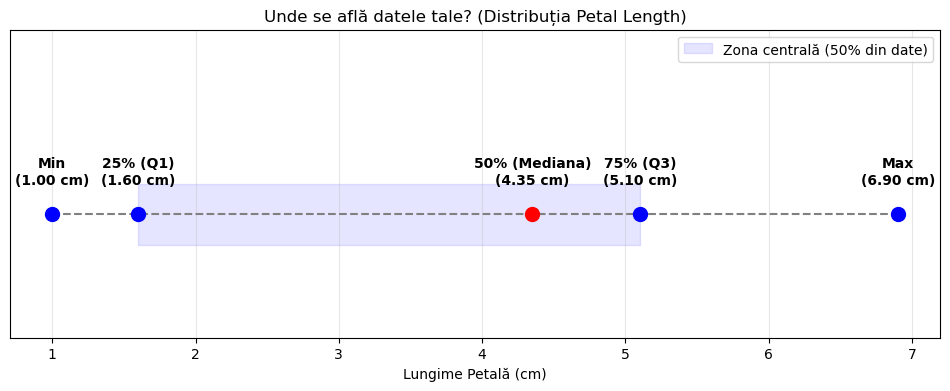

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Luăm datele pentru lungimea petalei
petal_length = iris.data[:, 2]
stats = df['petal length (cm)'].describe()

plt.figure(figsize=(12, 4))

# Desenăm "axa" setului de date
plt.hlines(1, stats['min'], stats['max'], colors='gray', linestyles='--')

# Marcăm pragurile importante
points = {
    'Min': stats['min'],
    '25% (Q1)': stats['25%'],
    '50% (Mediana)': stats['50%'],
    '75% (Q3)': stats['75%'],
    'Max': stats['max']
}

for label, val in points.items():
    color = 'red' if '50%' in label else 'blue'
    plt.plot(val, 1, 'o', markersize=10, color=color)
    plt.text(val, 1.05, f"{label}\n({val:.2f} cm)", ha='center', fontweight='bold')

# Evidențiem zona unde stau 50% din date (Interquartile Range)
plt.fill_between([stats['25%'], stats['75%']], 0.95, 1.05, color='blue', alpha=0.1, label='Zona centrală (50% din date)')

plt.ylim(0.8, 1.3)
plt.title("Unde se află datele tale? (Distribuția Petal Length)")
plt.yticks([]) # Ascundem axa Y pentru că e doar o reprezentare 1D
plt.xlabel("Lungime Petală (cm)")
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X = iris.data    # Caracteristicile (lungime/lățime petală și sepală)
y = iris.target  # Eticheta (specia: 0, 1 sau 2)

# Împărțim datele: 70% pentru antrenament, 30% pentru testare
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
from sklearn.tree import DecisionTreeClassifier
# Model fără limitări
overfitted_tree = DecisionTreeClassifier(random_state=42) 
overfitted_tree.fit(X_train, y_train)

print(f"Acuratețe Antrenament: {overfitted_tree.score(X_train, y_train):.2f}")
print(f"Acuratețe Test: {overfitted_tree.score(X_test, y_test):.2f}")

Acuratețe Antrenament: 1.00
Acuratețe Test: 1.00


In [9]:
# Model limitat la o adâncime de 3 niveluri
balanced_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)
balanced_tree.fit(X_train, y_train)

print(f"Acuratețe Antrenament: {balanced_tree.score(X_train, y_train):.2f}")
print(f"Acuratețe Test: {balanced_tree.score(X_test, y_test):.2f}")

Acuratețe Antrenament: 0.94
Acuratețe Test: 1.00


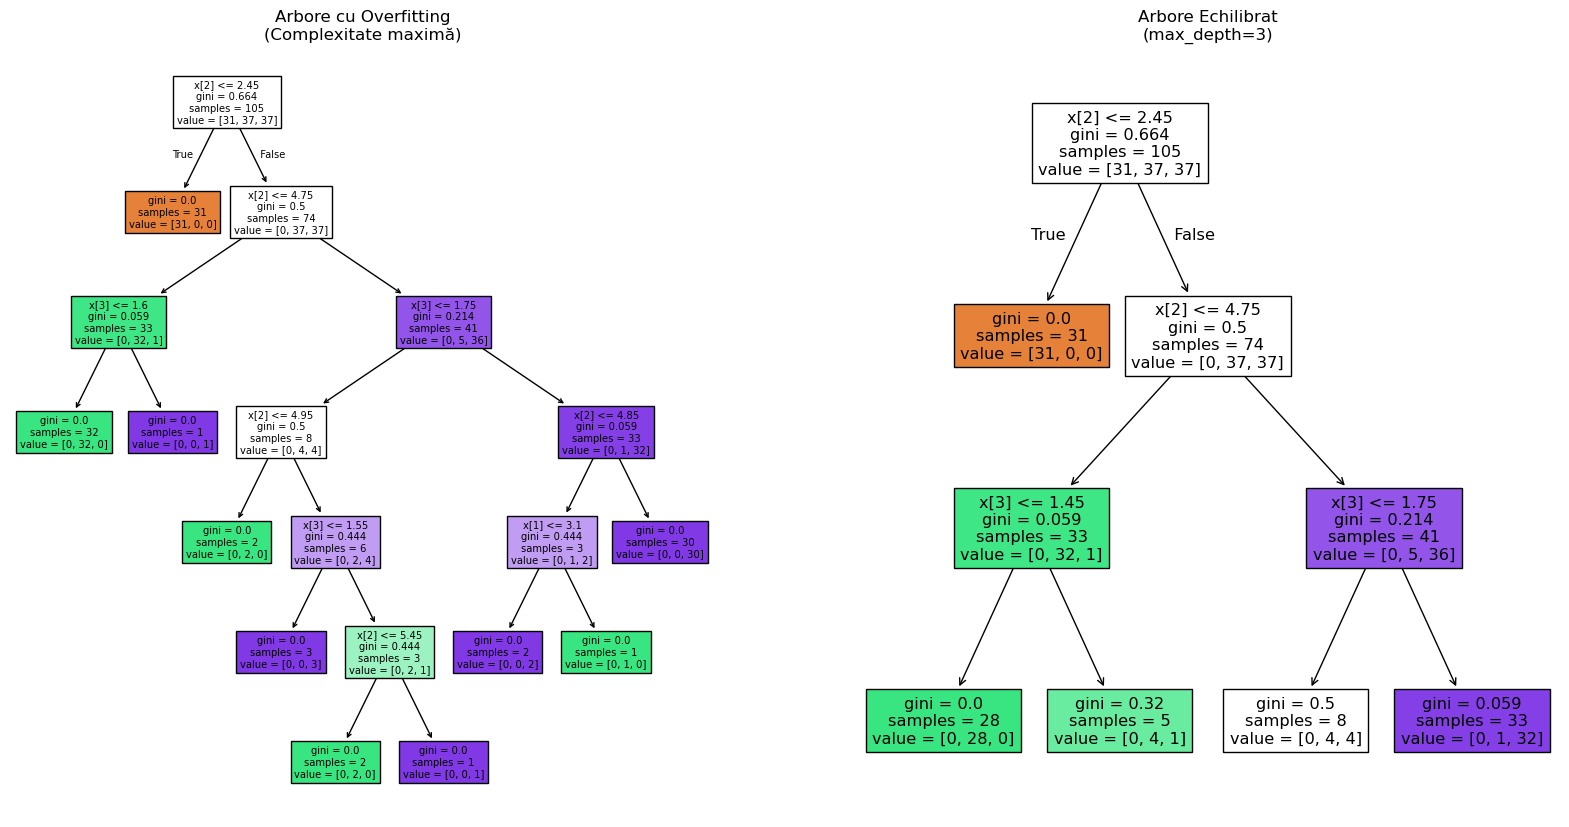

In [10]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,10))

# Vizualizare Overfitting
plot_tree(overfitted_tree, filled=True, ax=axes[0])
axes[0].set_title("Arbore cu Overfitting\n(Complexitate maximă)")

# Vizualizare Balanced
plot_tree(balanced_tree, filled=True, ax=axes[1])
axes[1].set_title("Arbore Echilibrat\n(max_depth=3)")

plt.show()